Importing libraries

In [1]:
import os
import albumentations as A
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Configurações de seed para reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

This code loads all images from folders, resizes and normalizes them, and gives you image data and class labels ready for model training.

In [2]:
def load_and_preprocess_images(data_dir, target_size=(224, 224)):
    images = []
    labels = []
    classes = os.listdir(data_dir)
    for label, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, target_size)
                img = img / 255.0  # Normalização
                images.append(img)
                labels.append(label)
    return np.array(images), np.array(labels)

# Diretório de dados
data_dir = "D:\dataset_initial"
X, y = load_and_preprocess_images(data_dir)

Splitting the data 70% for training and 15% for testing, 15% for validation

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [5]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_flat, y_train)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_under, y_train_under)
X_train_resampled = X_train_resampled.reshape(-1, 224, 224, 3)

Data augmentation : for each original image 3 more aumented images are created
SMOTE will chose the dataset with less images,sso negative is 142 so now 
positives -> 4* 147 = 588
negatives -> 4*147 = 588
total = 1176


In [6]:
augmentation_pipeline = A.Compose([
    A.Rotate(limit=15, p=0.7),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.3),
    A.GridDistortion(p=0.3),
    A.CLAHE(p=0.2),
    A.RandomScale(scale_limit=0.1, p=0.5),
    A.Perspective(p=0.3)
])
def augment_images(images, labels, augmentation_pipeline, augmentation_factor=3):
    augmented_images = []
    augmented_labels = []
    for img, label in zip(images, labels):
        augmented_images.append(img)
        augmented_labels.append(label)
        for _ in range(augmentation_factor):
            img_bgr = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
            augmented = augmentation_pipeline(image=img_bgr)['image']
            augmented_rgb = cv2.cvtColor(augmented, cv2.COLOR_BGR2RGB) / 255.0
            if augmented_rgb.shape == (224, 224, 3):
                augmented_images.append(augmented_rgb)
                augmented_labels.append(label)
    return np.array(augmented_images), np.array(augmented_labels)

X_train_aug, y_train_aug = augment_images(X_train_resampled, y_train_resampled, augmentation_pipeline)

In [7]:
def create_model():
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers[:-150]:
        layer.trainable = False
    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(1024, activation='relu', kernel_regularizer=l2(0.002)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(512, activation='relu', kernel_regularizer=l2(0.003)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

You're training your model 5 times, each time using a different part of the data for validation.
This helps you check if your model performs consistently and avoids overfitting to just one train/val split.

In [8]:
# Configuração de parâmetros para o treinamento
batch_size = 32
epochs = 15
k_folds = 5

# Inicializar StratifiedKFold
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Armazenar métricas de cada fold
fold_metrics = []

# K-Fold Cross Validation
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_aug, y_train_aug)):
    print(f"Treinando Fold {fold + 1}/{k_folds}")
    
    # Divisão dos dados em treino e validação para o fold atual
    X_train_fold, X_val_fold = X_train_aug[train_idx], X_train_aug[val_idx]
    y_train_fold, y_val_fold = y_train_aug[train_idx], y_train_aug[val_idx]

    # Criação do modelo
    model = create_model()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=BinaryCrossentropy(),
        metrics=['accuracy']
    )
    
    # Treinamento
    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        batch_size=batch_size,
        epochs=epochs,
        verbose=1
    )
    
    # Avaliação no conjunto de validação
    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold + 1}: Loss = {val_loss:.4f}, Accuracy = {val_accuracy:.4f}")

    # Salvar métricas
    fold_metrics.append({
        'fold': fold + 1,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy
    })


Treinando Fold 1/5
Epoch 1/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 206s 9s/step - accuracy: 0.5568 - loss: 5.2357 - val_accuracy: 0.5143 - val_loss: 5.0464
Epoch 2/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 99s 7s/step - accuracy: 0.7778 - loss: 4.8725 - val_accuracy: 0.6667 - val_loss: 4.9048
Epoch 3/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 97s 7s/step - accuracy: 0.8239 - loss: 4.6577 - val_accuracy: 0.7714 - val_loss: 4.7942
Epoch 4/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 88s 6s/step - accuracy: 0.8547 - loss: 4.5755 - val_accuracy: 0.8000 - val_loss: 4.6973
Epoch 5/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 92s 7s/step - accuracy: 0.9237 - loss: 4.3902 - val_accuracy: 0.8000 - val_loss: 4.6058
Epoch 6/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 93s 7s/step - accuracy: 0.8575 - loss: 4.4135 - val_accuracy: 0.8190 - val_loss: 4.5255
Epoch 7/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 106s 8s/step - accuracy: 0.8905 - loss: 4.3202 - val_accuracy: 0.8381 - val_loss: 4.4607
Epoch 8/15
14/14 ━━━━━━━━━━━━━━━━━━━━ 123s 9s/step - accuracy: 0.9319 - loss: 4.1852 - val_accura

metrics

In [9]:
# Previsões no conjunto de teste
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Cálculo de métricas
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)
average_precision = average_precision_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Exibição das métricas
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Average Precision: {average_precision:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 6s/step
Precision: 0.9818
Recall: 0.8438
F1 Score: 0.9076
Average Precision: 0.9863
Confusion Matrix:
[[21  1]
 [10 54]]


In [10]:
model.save("model_fold5.h5")


In [11]:
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model.save(f"model_fold5_{timestamp}.h5")


In [12]:

model.save("D:\model_fold5.h5")


In [1]:
from tensorflow.keras.models import load_model

model = load_model(r"D:\model_fold5.h5")

# It is drawing 



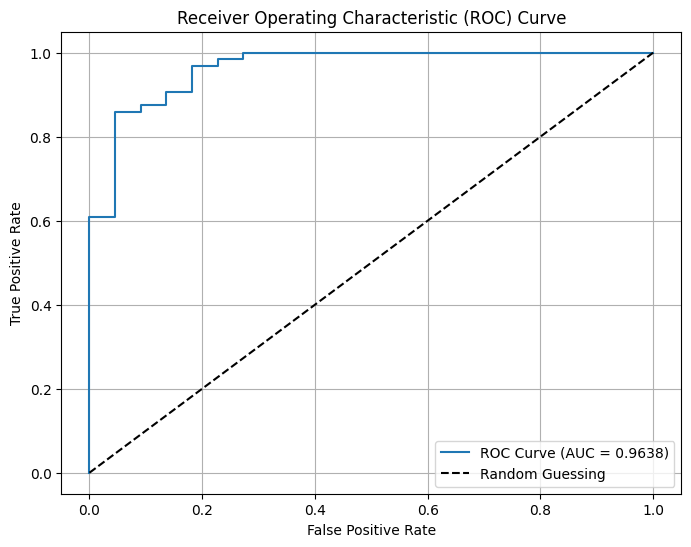

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid()
plt.show()

# model
That steep line from (0.0, 0.0) to around (0.0, 0.8) means:Your model can find 80% of sickle cells while making almost zero mistakes on normal cells.

In Simple Terms

X stays at 0.0 = Not calling any normal cells "sickle cell" by mistake
Y goes up to 0.8 = Finding 8 out of 10 sickle cells correctly

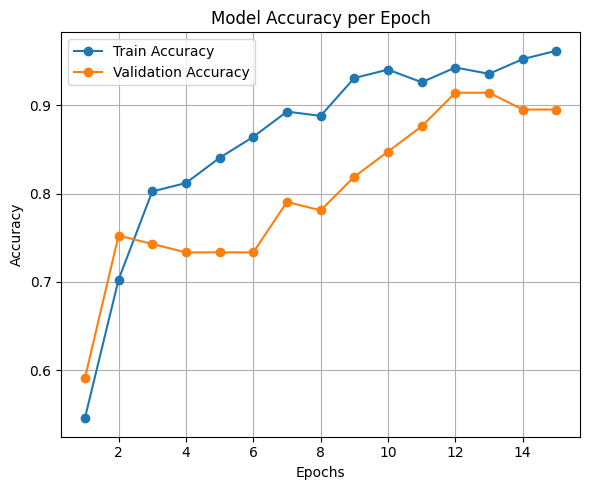

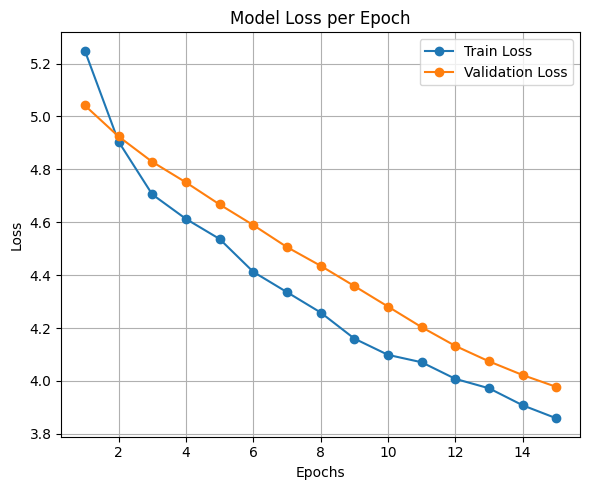

In [21]:
import matplotlib.pyplot as plt

# Extract values from training history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_accuracy) + 1)

# Plot Accuracy
plt.figure(figsize=(6, 5))
plt.plot(epochs, train_accuracy, label='Train Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Loss
plt.figure(figsize=(6, 5))
plt.plot(epochs, train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Model Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


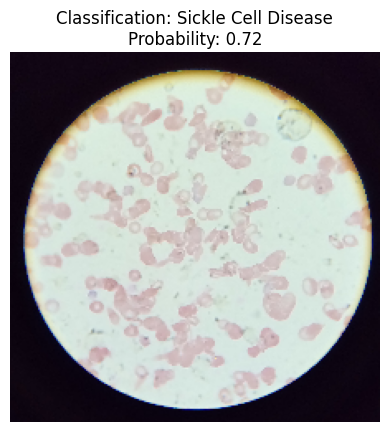

In [22]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Caminho para a imagem individual
image_path = "D:\dataset_initial\Positives\\1.jpg"

# Carregar a imagem no tamanho esperado pelo modelo (224x224)
img = load_img(image_path, target_size=(224, 224))
img_array = img_to_array(img)

# Normalizar os valores da imagem (entre 0 e 1)
img_array = img_array / 255.0

# Adicionar dimensão extra para simular um lote de tamanho 1
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)



# Exibir a imagem com a classificação
plt.imshow(img)
plt.title(f"Classification: {'Sickle Cell Disease' if prediction[0] > 0.5 else 'Healthy'}\nProbability: {prediction[0][0]:.2f}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step


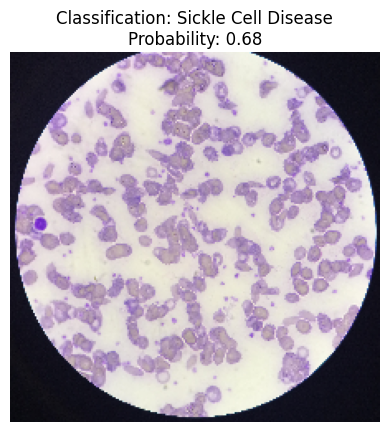

In [ ]:

from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Caminho para a imagem individual
image_path = "D:\\dataset_initial\\Positives\\29.jpg"

# Carregar a imagem no tamanho esperado pelo modelo (224x224)
img = load_img(image_path, target_size=(224, 224))
img_array = img_to_array(img)

# Normalizar os valores da imagem (entre 0 e 1)
img_array = img_array / 255.0

# Adicionar dimensão extra para simular um lote de tamanho 1
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)



# Exibir a imagem com a classificação
plt.imshow(img)
plt.title(f"Classification: {'Sickle Cell Disease' if prediction[0] > 0.5 else 'Healthy'}\nProbability: {prediction[0][0]:.2f}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


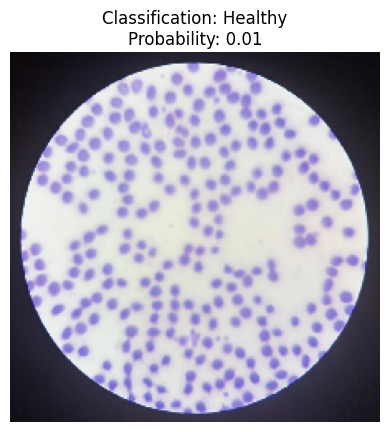

In [24]:


from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Caminho para a imagem individual
image_path = "D:\\dataset_initial\\Negatives\\N_3.jpg"

# Carregar a imagem no tamanho esperado pelo modelo (224x224)
img = load_img(image_path, target_size=(224, 224))
img_array = img_to_array(img)

# Normalizar os valores da imagem (entre 0 e 1)
img_array = img_array / 255.0

# Adicionar dimensão extra para simular um lote de tamanho 1
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)



# Exibir a imagem com a classificação
plt.imshow(img)
plt.title(f"Classification: {'Sickle Cell Disease' if prediction[0] > 0.5 else 'Healthy'}\nProbability: {prediction[0][0]:.2f}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


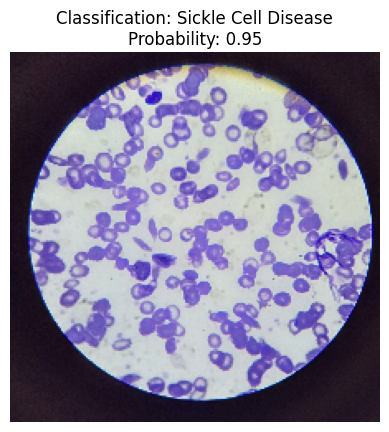

In [62]:


from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Caminho para a imagem individual
image_path = "D:\\dataset_initial\\Positives\\3.jpg"

# Carregar a imagem no tamanho esperado pelo modelo (224x224)
img = load_img(image_path, target_size=(224, 224))
img_array = img_to_array(img)

# Normalizar os valores da imagem (entre 0 e 1)
img_array = img_array / 255.0

# Adicionar dimensão extra para simular um lote de tamanho 1
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)



# Exibir a imagem com a classificação
plt.imshow(img)
plt.title(f"Classification: {'Sickle Cell Disease' if prediction[0] > 0.5 else 'Healthy'}\nProbability: {prediction[0][0]:.2f}")
plt.axis("off")
plt.show()